<a href="https://colab.research.google.com/github/TerteryanTatev/Data-Science-Data-Analysis/blob/main/DataCleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import missingno as msno
import matplotlib.pyplot as plt


[Link of DataSet](https://www.kaggle.com/datasets/rashikrahmanpritom/data-science-job-posting-on-glassdoor/data?select=Cleaned_DS_Jobs.csv)

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/AI 2.1/DataSets/Uncleaned_DS_jobs.csv")
print(df.head())

   index          Job Title               Salary Estimate  \
0      0  Sr Data Scientist  $137K-$171K (Glassdoor est.)   
1      1     Data Scientist  $137K-$171K (Glassdoor est.)   
2      2     Data Scientist  $137K-$171K (Glassdoor est.)   
3      3     Data Scientist  $137K-$171K (Glassdoor est.)   
4      4     Data Scientist  $137K-$171K (Glassdoor est.)   

                                     Job Description  Rating  \
0  Description\n\nThe Senior Data Scientist is re...     3.1   
1  Secure our Nation, Ignite your Future\n\nJoin ...     4.2   
2  Overview\n\n\nAnalysis Group is one of the lar...     3.8   
3  JOB DESCRIPTION:\n\nDo you have a passion for ...     3.5   
4  Data Scientist\nAffinity Solutions / Marketing...     2.9   

              Company Name       Location            Headquarters  \
0         Healthfirst\n3.1   New York, NY            New York, NY   
1             ManTech\n4.2  Chantilly, VA             Herndon, VA   
2      Analysis Group\n3.8     Boston, MA

In [ ]:
df.describe()

,index,Rating,Founded
count,672.000000,672.000000,672.000000
mean,335.500000,3.518601,1635.529762
std,194.133974,1.410329,756.746640
min,0.000000,-1.000000,-1.000000
25%,167.750000,3.300000,1917.750000
50%,335.500000,3.800000,1995.000000
75%,503.250000,4.300000,2009.000000
max,671.000000,5.000000,2019.000000


In [ ]:
df.duplicated().sum()

np.int64(0)

<Axes: >

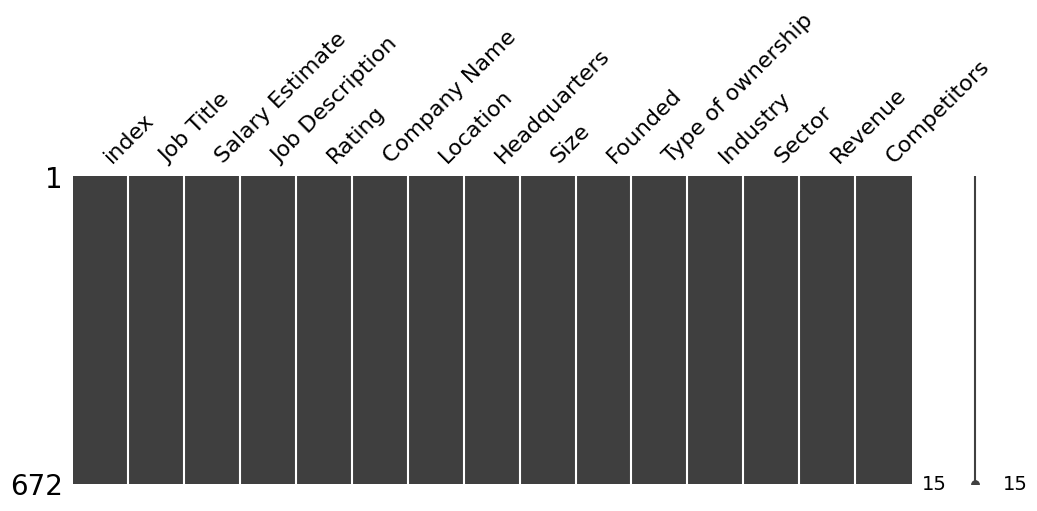

In [ ]:
msno.matrix(df, figsize=(12,4))

In [ ]:
df.isnull().sum()

,0
index,0
Job Title,0
Salary Estimate,0
Job Description,0
Rating,0
Company Name,0
Location,0
Headquarters,0
Size,0
Founded,0


{'whiskers': [<matplotlib.lines.Line2D at 0x7db6b4585f90>,
 'caps': [<matplotlib.lines.Line2D at 0x7db6b4587750>,
 'boxes': [<matplotlib.lines.Line2D at 0x7db6b4585290>],
 'medians': [<matplotlib.lines.Line2D at 0x7db6b4591090>],
 'fliers': [<matplotlib.lines.Line2D at 0x7db6b4591b90>],
 'means': []}

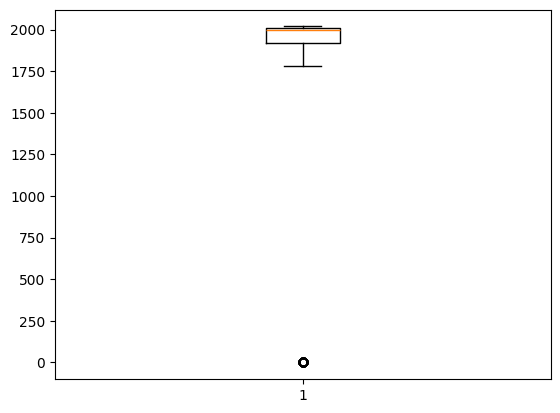

In [ ]:
plt.boxplot(x = df['Founded'])

In [ ]:
df.replace(-1,np.nan, inplace=True)

<Axes: >

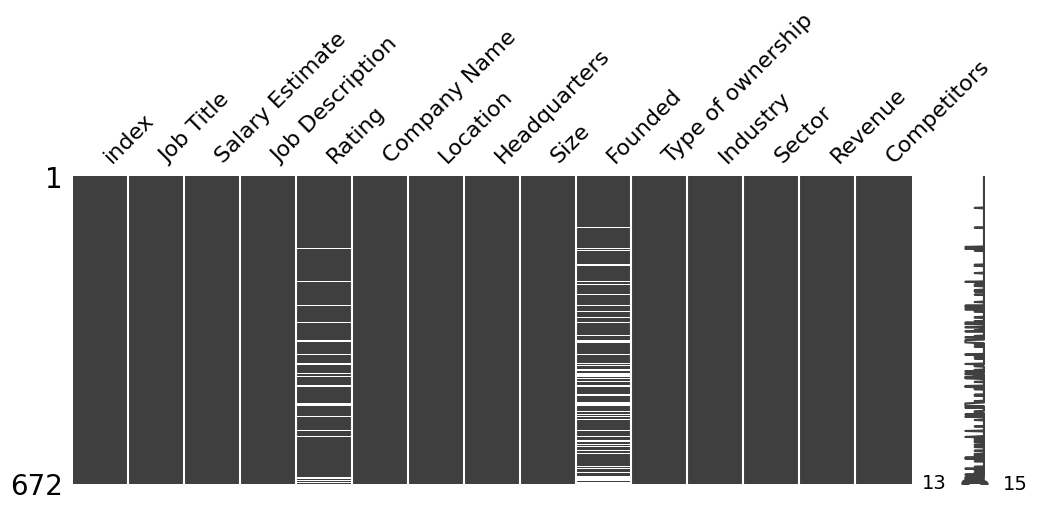

In [ ]:
msno.matrix(df, figsize=(12,4))

In [ ]:
df['Headquarters'] == '-1'

,Headquarters
0,False
1,False
2,False
3,False
4,False
...,...
667,False
668,True
669,True
670,False


In [ ]:
df.loc[df['Headquarters'] == '-1', 'Headquarters'] = df.loc[df['Headquarters'] == '-1', 'Location']


In [ ]:
(df['Headquarters'] == '-1').sum()

np.int64(0)

In [ ]:
df.replace('-1',np.nan, inplace=True)

<Axes: >

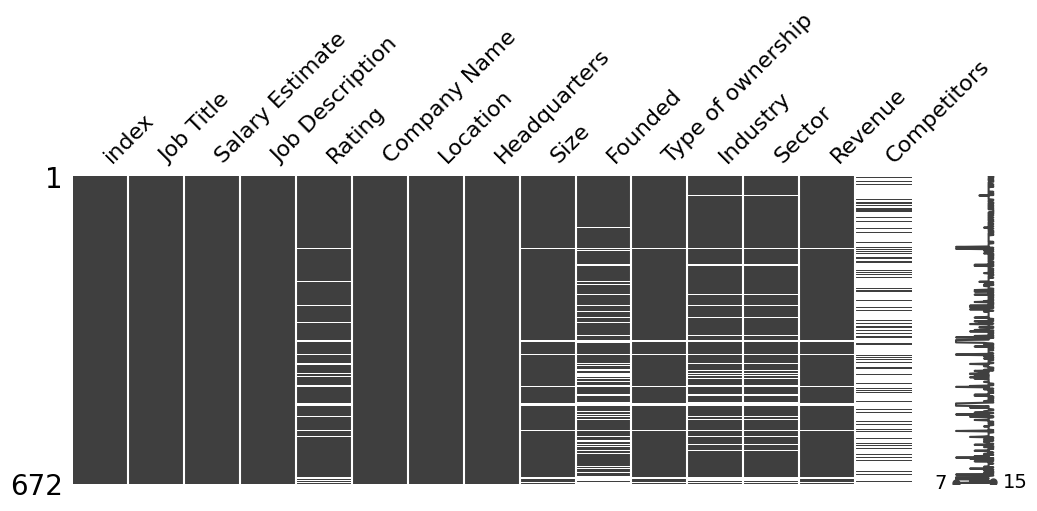

In [ ]:
msno.matrix(df, figsize=(12,4))

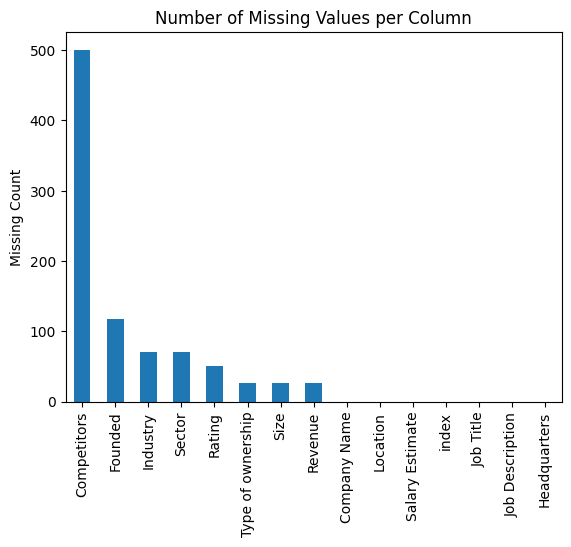

In [ ]:

df.isnull().sum().sort_values(ascending=False).plot(kind='bar')
plt.title('Number of Missing Values per Column')
plt.ylabel('Missing Count')
plt.show()

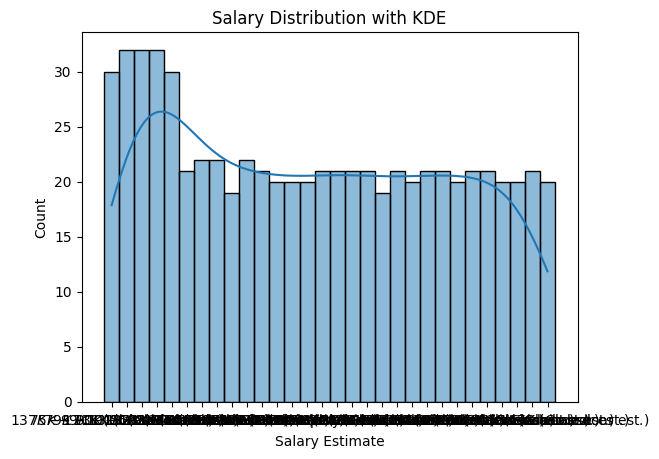

In [ ]:
sns.histplot(df['Salary Estimate'], kde=True, bins=10)
plt.title("Salary Distribution with KDE")
plt.show()

In [ ]:
(df['Rating'] > 5).sum()

np.int64(0)

{'whiskers': [<matplotlib.lines.Line2D at 0x7db6b4157050>,
 'caps': [<matplotlib.lines.Line2D at 0x7db6b4027150>,
 'boxes': [<matplotlib.lines.Line2D at 0x7db6b419b290>],
 'medians': [<matplotlib.lines.Line2D at 0x7db6b3fc1750>],
 'fliers': [<matplotlib.lines.Line2D at 0x7db6b3fc3010>],
 'means': []}

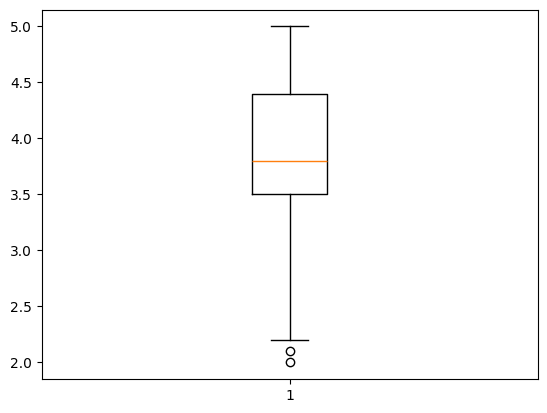

In [ ]:
plt.boxplot(df['Rating'].dropna())

In [ ]:
import re

def parse_salary(salary):
    try:
        salary_clean = re.sub(r'[^\d\-]', '', salary)
        parts = salary_clean.split('-')
        if len(parts) == 2:
            min_salary = int(parts[0])
            max_salary = int(parts[1])
            avg_salary = (min_salary + max_salary) / 2
            return pd.Series([min_salary, max_salary, avg_salary])
        else:
            return pd.Series([np.nan, np.nan, np.nan])
    except:
        return pd.Series([np.nan, np.nan, np.nan])


In [ ]:
df[['min_salary', 'max_salary', 'avg_salary']] = df['Salary Estimate'].apply(parse_salary)


{'whiskers': [<matplotlib.lines.Line2D at 0x7db6b3d90e10>,
 'caps': [<matplotlib.lines.Line2D at 0x7db6b3d92fd0>,
 'boxes': [<matplotlib.lines.Line2D at 0x7db6b3d9a010>],
 'medians': [<matplotlib.lines.Line2D at 0x7db6b3d92f50>],
 'fliers': [<matplotlib.lines.Line2D at 0x7db6b3d80090>],
 'means': []}

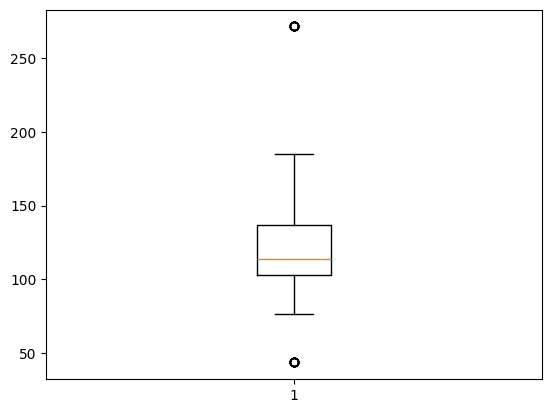

In [ ]:
plt.boxplot(x = df['avg_salary'])

In [ ]:
df.duplicated().sum()

np.int64(0)

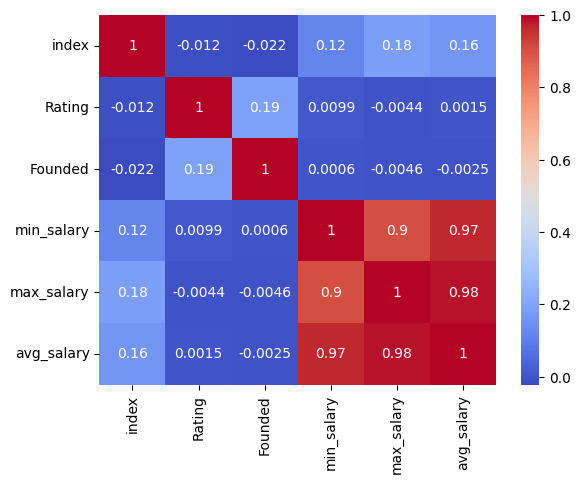

In [ ]:
numeric_df = df.select_dtypes(include='number')

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.show()
numeric_df.drop('index', axis = 1, inplace=True)

<Axes: xlabel='max_salary'>

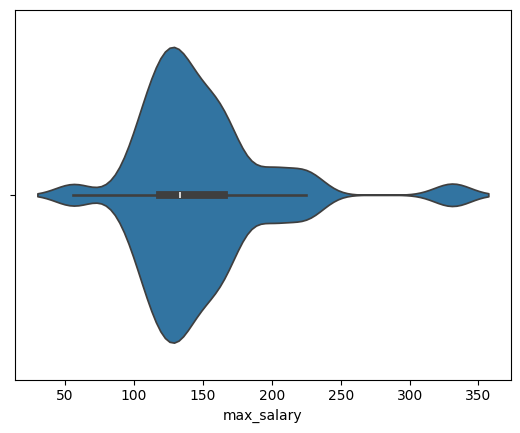

In [ ]:
# numeric_df.drop('Founded', axis='columns', inplace=True)

sns.violinplot(x = numeric_df['max_salary'])
# numeric_df